In [2]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 3
METRICS_NOTES = "Power Transformer"
PCA = False
scaler = 'power' # or 'standard' for StandardScaler



UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

In [ ]:
from shared_util.fetch import fetch_metric

pca_results_df = fetch_metric(run_id=2)
results_df = fetch_metric(run_id=1)



results_df[results_df['data'] == 'test'].head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,35,1,xgb,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.675963,0.472337,0.128680,0.767159,0.220392,4709.0,883.0,5979.0,268.0,2025-10-27 23:41:10.147287
11,24,1,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674749,0.264465,0.109538,0.920938,0.195789,2071.0,1060.0,8617.0,91.0,2025-10-27 23:23:22.331265
4,31,1,svc,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674099,0.418954,0.122263,0.805387,0.212298,4033.0,927.0,6655.0,224.0,2025-10-27 23:36:02.302171
7,28,1,sgd,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.669999,0.421995,0.122847,0.805387,0.213177,4069.0,927.0,6619.0,224.0,2025-10-27 23:24:32.414371


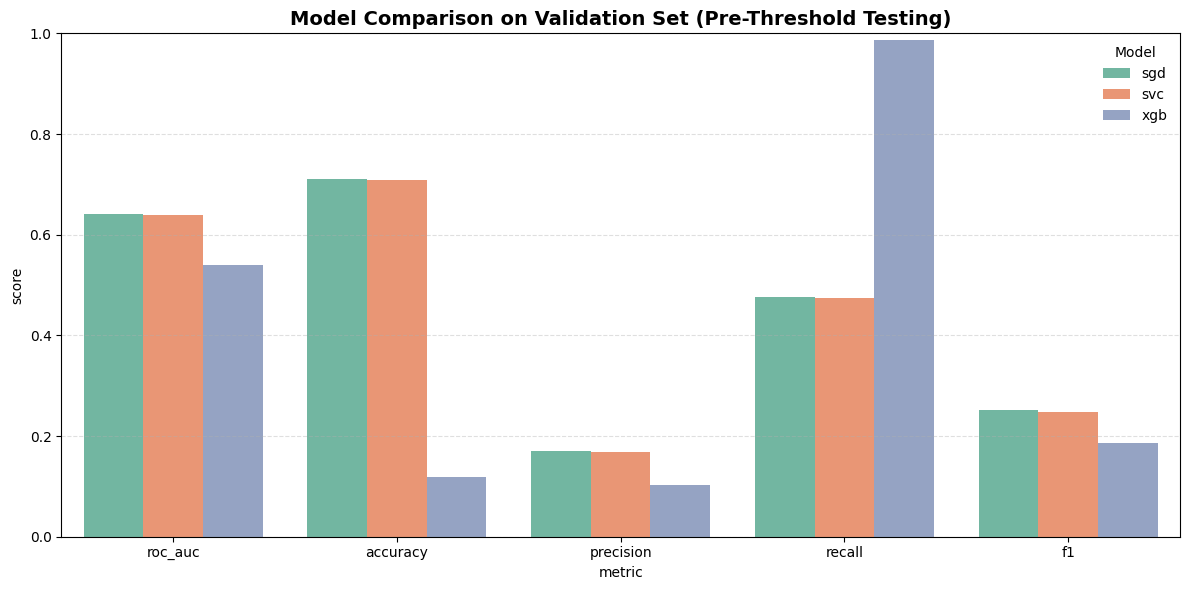

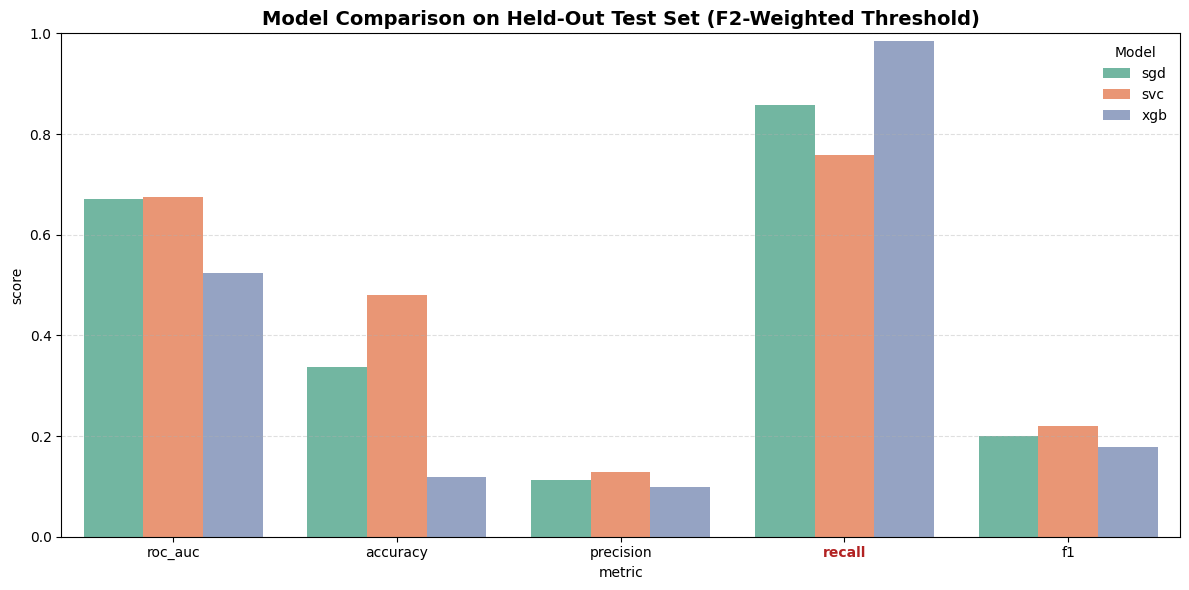

In [22]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(pca_results_df, METRICS_DB_ID)

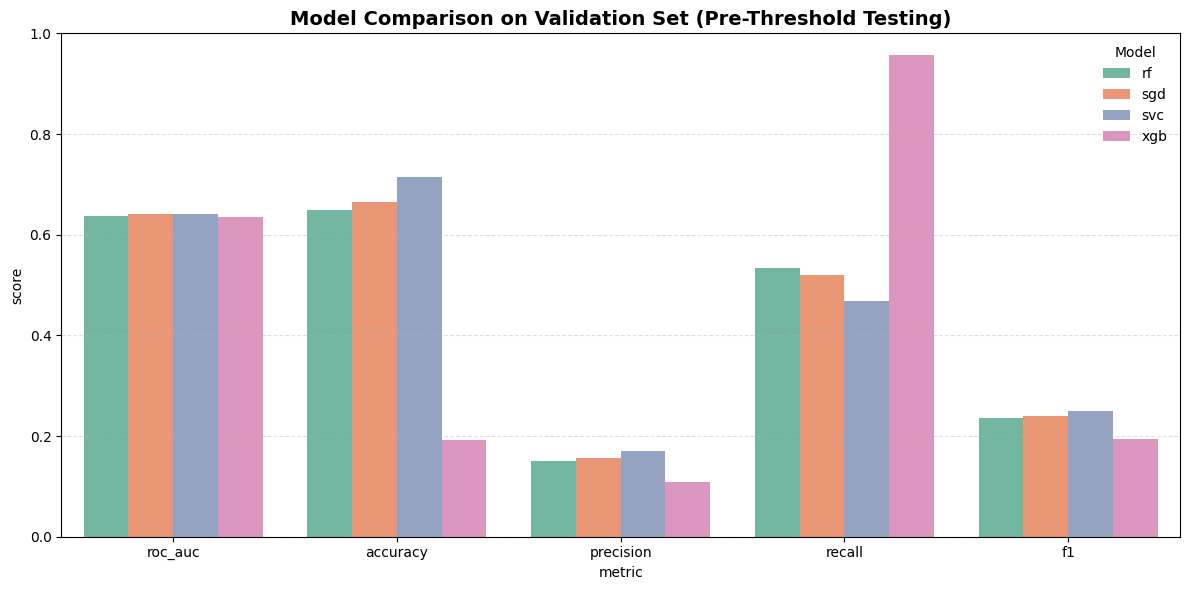

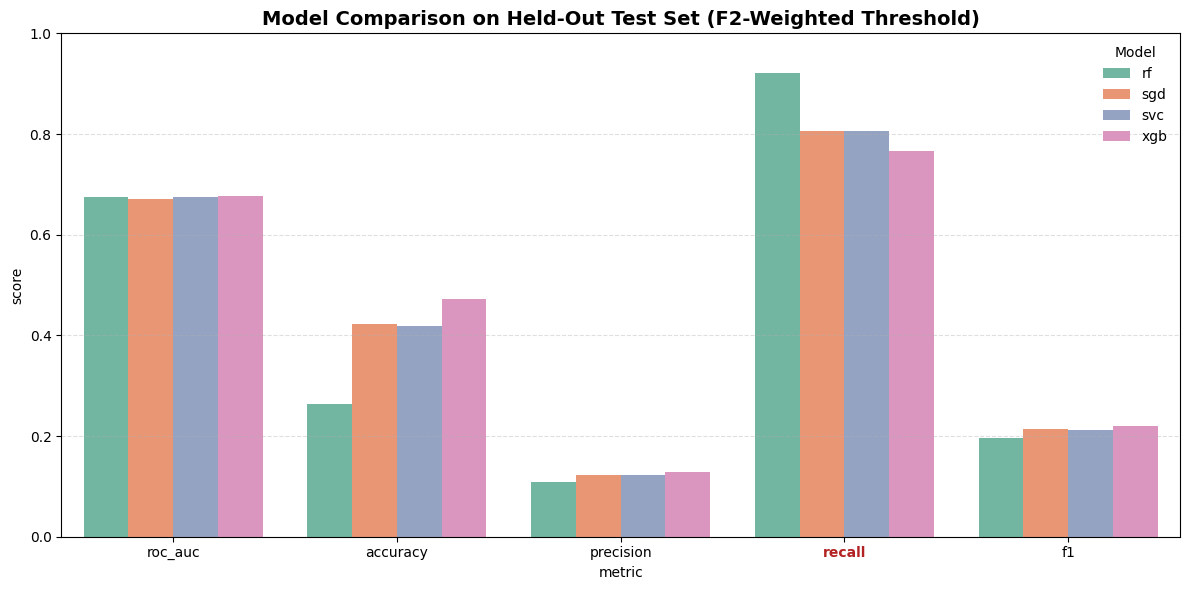

In [23]:
plot_metrics(results_df, 1)

In [ ]:
print('--pca--')
summary_by_auc(pca_results_df, plot_id=METRICS_DB_ID)
summary_by_recall(pca_results_df)

print('--no pca--')
summary_by_auc(results_df, plot_id=1)
summary_by_recall(results_df)



--pca--
Models by ROC_AUC


,model,roc_auc
0,svc,0.675
1,sgd,0.671
10,xgb,0.525


Models by Recall


,model,recall
7,xgb,0.984
0,sgd,0.857
4,svc,0.758


--no pca--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.676
1,rf,0.675
2,svc,0.674
3,sgd,0.670


Models by Recall


,model,recall
11,rf,0.921
7,sgd,0.805
4,svc,0.805
0,xgb,0.767


### Hyperparameter Display

In [23]:
from shared_util.fetch import fetch_hyperparams
import pandas as pd
import ast
import re

h_params_df = fetch_hyperparams(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,5.325258e-01
1,model__gamma,4.744428e+00
2,model__learning_rate,2.900333e-01
3,model__max_depth,3.000000e+00
4,model__min_child_weight,9.000000e+00
5,model__n_estimators,7.640000e+02
6,model__reg_alpha,4.132918e-07
7,model__reg_lambda,5.285382e-02
8,model__scale_pos_weight,1.614304e+01
9,model__subsample,8.049983e-01


Model: svc


,param,value
0,model__C,4.418442
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.001
1,model__shuffle,True
2,model__penalty,l2
3,model__max_iter,100
4,model__loss,hinge
5,model__learning_rate,adaptive
6,model__l1_ratio,0.5
7,model__eta0,0.0003
8,model__class_weight,None
9,model__average,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

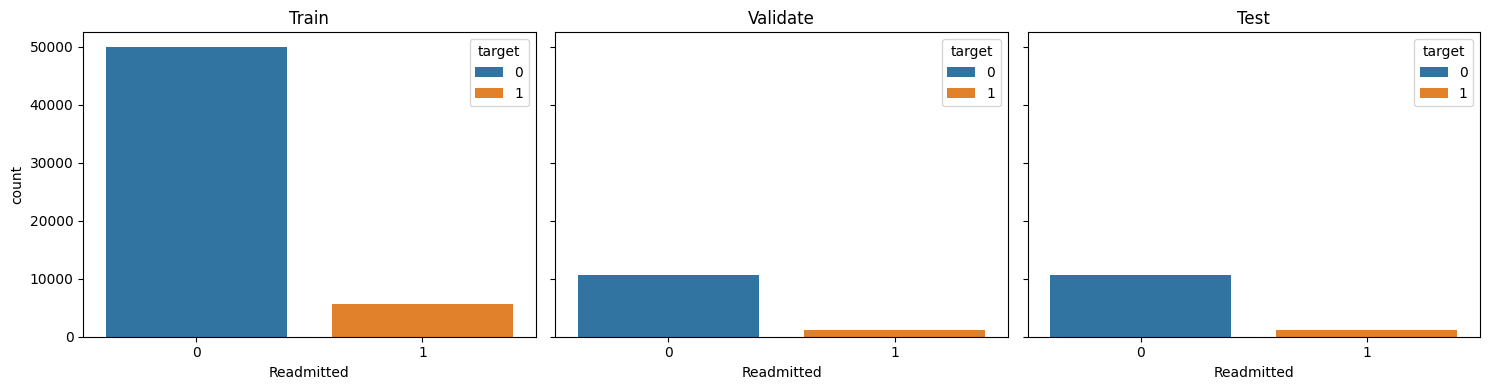

In [ ]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [6]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.593 0.592 0.597 0.6   0.589]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.654 0.635 0.624 0.653 0.632]
mean roc_auc score: , 0.640
Duration: 0 hrs, 0 mins, 19.0 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
6,number_inpatient,0.067655,0.009661
5,number_emergency,0.006267,0.001169
3,num_medications,0.003834,0.003512
7,number_diagnoses,0.003263,0.003882
0,time_in_hospital,0.002859,0.002259
2,num_procedures,0.002400,0.002274
15,diag1_group_respiratory,0.002164,0.001035
1,num_lab_procedures,0.002108,0.001784
37,specialty_cat_cardiology,0.002038,0.000482
12,diag1_group_musculoskeletal,0.001686,0.000573


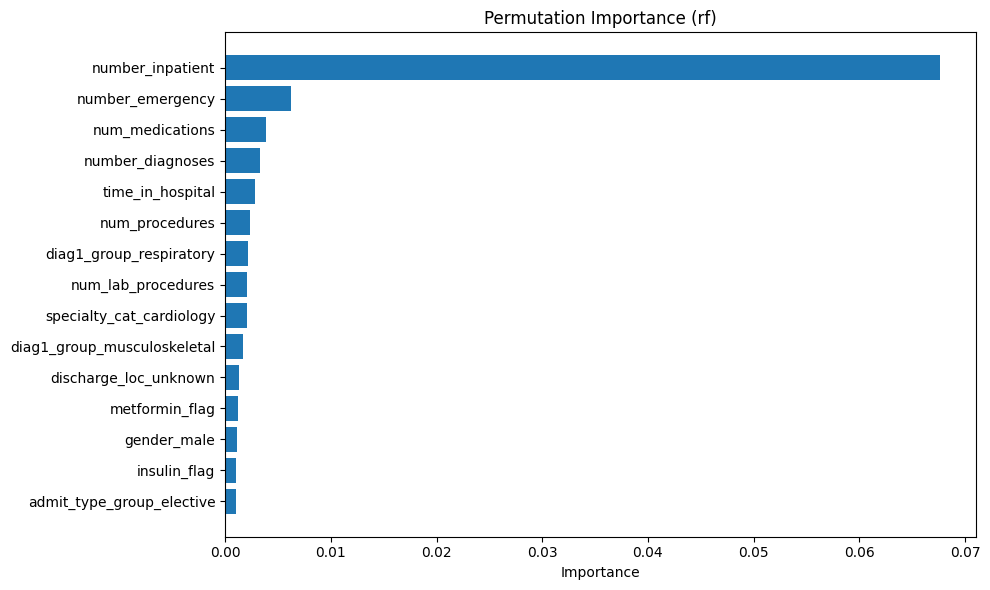

Duration: 0 hrs, 0 mins, 42.3 secs


In [7]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [8]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Best ROC_AUC (cv): 0.658743270492685
Best params: {'model__oob_score': False, 'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 0.2, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 32.2 secs


In [9]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6369706741016923
Accuracy:      0.6484578536011429
F1 score:      0.23598173515981735
Precision:     0.15139442231075698
Recall:        0.5347682119205298

Confusion matrix:

TN: 7070, FP: 3621, FN: 562, TP: 646

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77     10691
           1       0.15      0.53      0.24      1208

    accuracy                           0.65     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.65      0.72     11899



Best threshold (F2): 0.3734
Precision: 0.112  Recall: 0.913  F2: 0.376


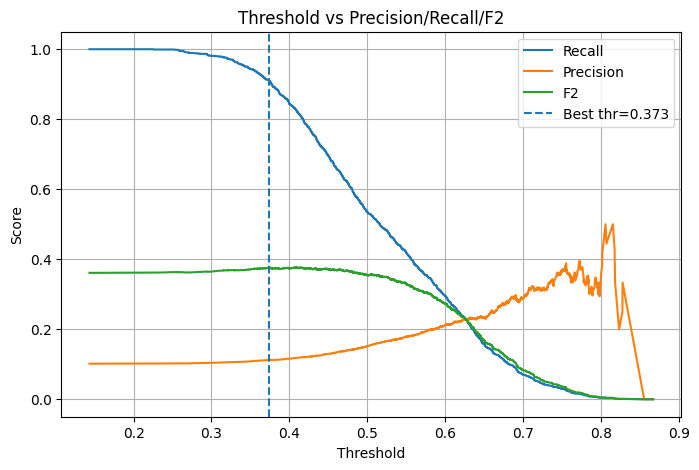

ROC_AUC:     0.674748705239391
Accuracy:      0.2644649041304164
F1 score:      0.1957886959734023
Precision:     0.10953807998346594
Recall:        0.9209383145091226

Confusion matrix:

TN: 2071, FP: 8617, FN: 91, TP: 1060

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.19      0.32     10688
           1       0.11      0.92      0.20      1151

    accuracy                           0.26     11839
   macro avg       0.53      0.56      0.26     11839
weighted avg       0.88      0.26      0.31     11839



In [10]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

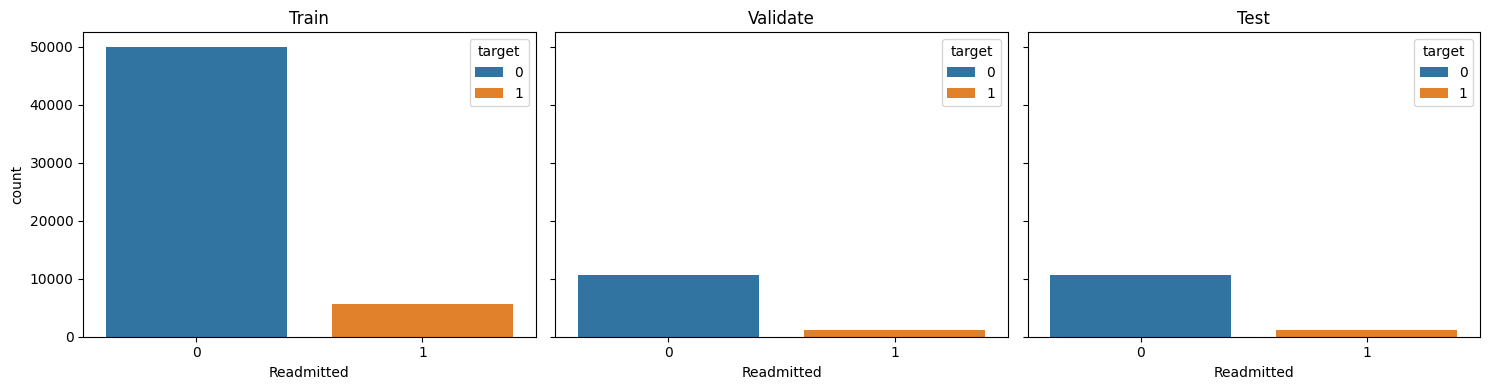

In [3]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA
)



,feature,importance_mean,importance_std
6,number_inpatient,0.057640,0.014495
15,diag1_group_respiratory,0.017746,0.010611
66,i_hosp_time__diag1_group_other,0.009082,0.010528
67,i_hosp_time__diag1_group_respiratory,0.007560,0.003898
5,number_emergency,0.006427,0.003682
69,i_hosp_time__specialty_cat_internal_medicine,0.006264,0.006108
0,time_in_hospital,0.005690,0.005065
7,number_diagnoses,0.004743,0.001816
54,diabetesMed_flag,0.003864,0.001716
71,i_hosp_time__specialty_cat_other,0.003378,0.003785


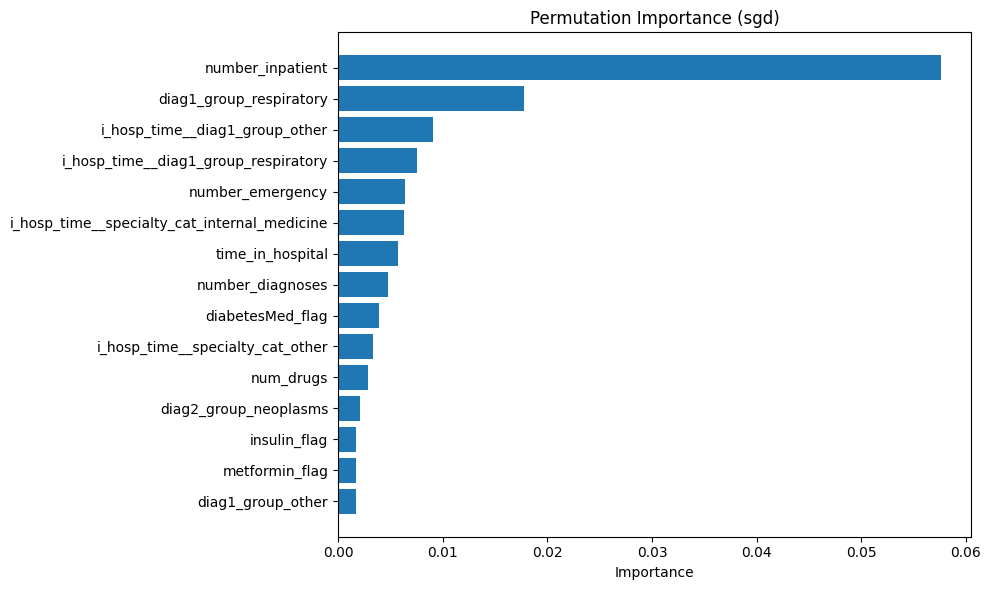

Duration: 0 hrs, 0 mins, 16.7 secs


In [4]:
if not PCA:
    sgd_pipe.permute_importance()

In [5]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.566 0.575 0.544 0.558 0.541]
mean roc_auc score: , 0.557
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.597 0.581 0.61  0.59  0.606]
mean roc_auc score: , 0.597
Duration: 0 hrs, 0 mins, 15.3 secs


In [6]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Best ROC_AUC (cv): 0.6553144259732783
Best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l2', 'model__max_iter': 100, 'model__loss': 'hinge', 'model__learning_rate': 'adaptive', 'model__l1_ratio': 0.5, 'model__eta0': 0.0003, 'model__class_weight': None, 'model__average': True, 'model__alpha': 0.0001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 43.2 secs


In [7]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6397203255074362
Accuracy:      0.6789646188755357
F1 score:      0.23843700159489634
Precision:     0.15703781512605042
Recall:        0.49503311258278143

Confusion matrix:

TN: 7481, FP: 3210, FN: 610, TP: 598

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.70      0.80     10691
           1       0.16      0.50      0.24      1208

    accuracy                           0.68     11899
   macro avg       0.54      0.60      0.52     11899
weighted avg       0.85      0.68      0.74     11899



Best threshold (F2): -0.9183
Precision: 0.119  Recall: 0.835  F2: 0.379


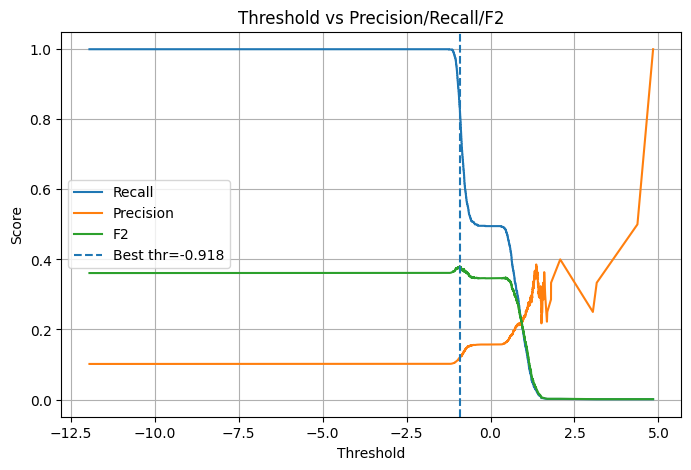

ROC_AUC:     0.6702977624247596
Accuracy:      0.3649801503505364
F1 score:      0.2039390088945362
Precision:     0.11612203062824068
Recall:        0.8366637706342311

Confusion matrix:

TN: 3358, FP: 7330, FN: 188, TP: 963

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.31      0.47     10688
           1       0.12      0.84      0.20      1151

    accuracy                           0.36     11839
   macro avg       0.53      0.58      0.34     11839
weighted avg       0.87      0.36      0.45     11839



In [8]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

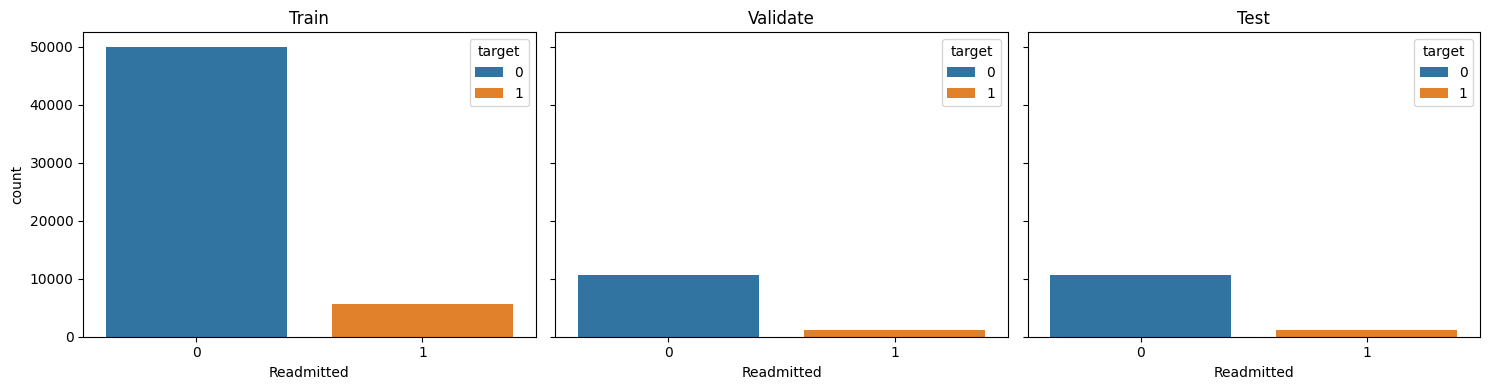

In [9]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA
)

In [10]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.638 0.633 0.645 0.66  0.632]
mean roc_auc score: , 0.642
Duration: 0 hrs, 0 mins, 14.7 secs


In [19]:
# slow
# svc_pipe.permute_importance()

In [11]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False, True],      
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Best ROC_AUC (cv): 0.654553056986612
Best params: {'model__C': np.float64(4.418441521199722), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}
logged hyperparameters
Duration: 0 hrs, 10 mins, 15.2 secs


In [12]:
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6355052928718282
Accuracy:      0.6757710731994285
F1 score:      0.23905325443786982
Precision:     0.1569135163127913
Recall:        0.5016556291390728

Confusion matrix:

TN: 7435, FP: 3256, FN: 602, TP: 606

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.79     10691
           1       0.16      0.50      0.24      1208

    accuracy                           0.68     11899
   macro avg       0.54      0.60      0.52     11899
weighted avg       0.85      0.68      0.74     11899



Best threshold (F2): -0.7848
Precision: 0.135  Recall: 0.691  F2: 0.378


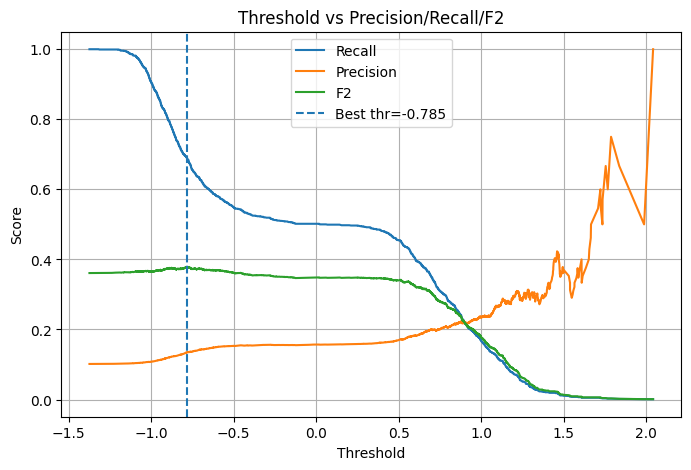

ROC_AUC:     0.6734677636473361
Accuracy:      0.524537545400794
F1 score:      0.22667948894078857
Precision:     0.13462793733681463
Recall:        0.7167680278019114

Confusion matrix:

TN: 5385, FP: 5303, FN: 326, TP: 825

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.50      0.66     10688
           1       0.13      0.72      0.23      1151

    accuracy                           0.52     11839
   macro avg       0.54      0.61      0.44     11839
weighted avg       0.86      0.52      0.61     11839



In [13]:
svc_pipe.test()

# XGBoost

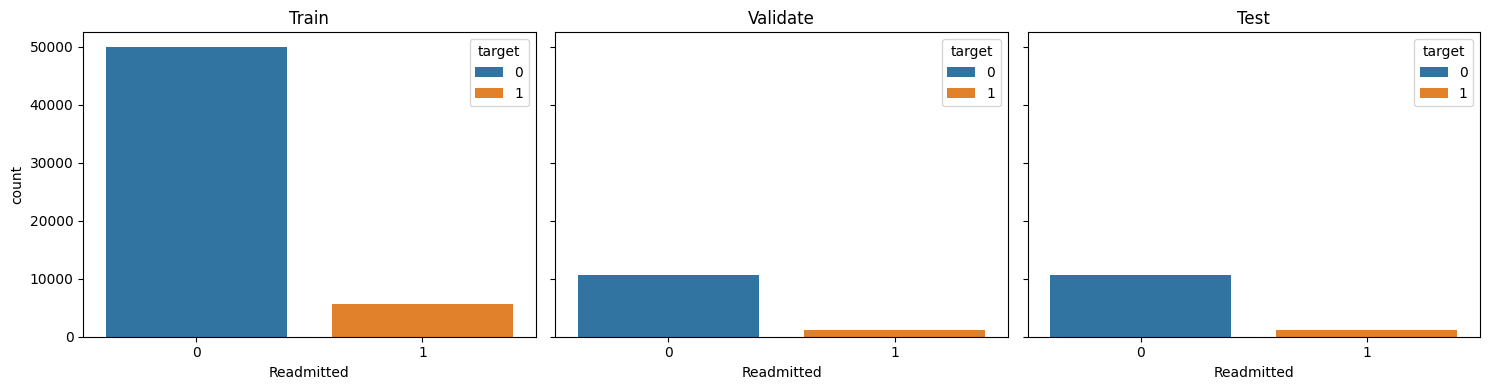

In [35]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None
)

In [25]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.576 0.585 0.574 0.583 0.574]
mean roc_auc score: , 0.578
-----Undersample Baseline-----
roc_auc score per fold:  [0.624 0.621 0.614 0.635 0.617]
mean roc_auc score: , 0.622
Duration: 0 hrs, 0 mins, 14.0 secs


,feature,importance_mean,importance_std
6,number_inpatient,0.062349,0.008398
3,num_medications,0.008727,0.001492
1,num_lab_procedures,0.007647,0.002758
5,number_emergency,0.006285,0.002415
0,time_in_hospital,0.004077,0.001113
7,number_diagnoses,0.003826,0.004539
37,specialty_cat_cardiology,0.002723,0.001296
15,diag1_group_respiratory,0.002660,0.002808
58,num_drugs,0.002467,0.000868
12,diag1_group_musculoskeletal,0.002421,0.000814


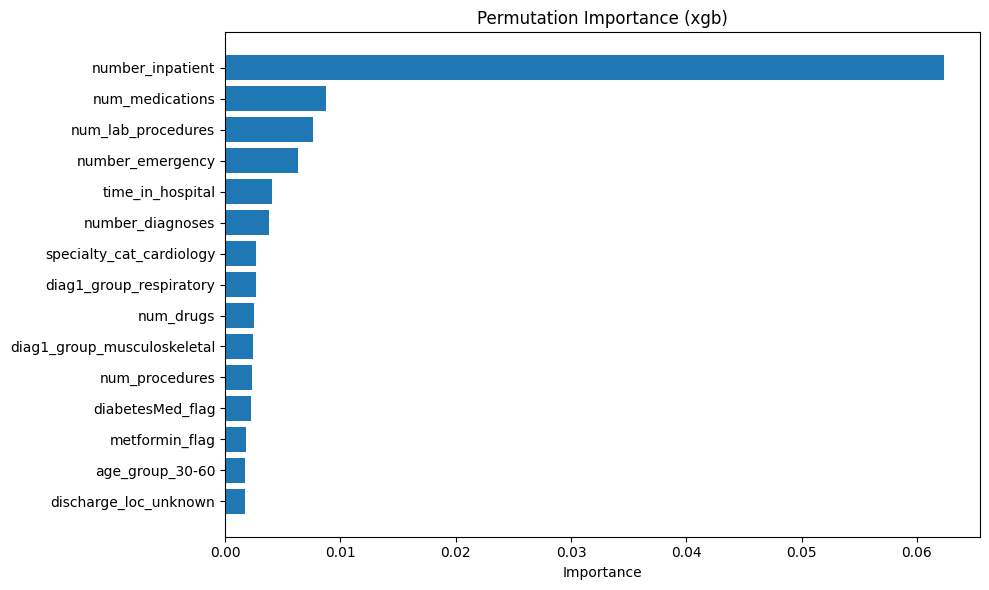

Duration: 0 hrs, 0 mins, 16.1 secs


In [26]:
if not PCA:
    xgb_pipe.permute_importance()

In [36]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(1000, 2500),
    'model__learning_rate': uniform(0.01, 0.10),
    'model__max_depth': randint(4, 15),
    'model__min_child_weight': randint(1, 8),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': [approx_spw],
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Best ROC_AUC (cv): 0.6539364171776265
Best params: {'model__colsample_bytree': np.float64(0.6521211214797689), 'model__gamma': np.float64(2.6237821581611893), 'model__learning_rate': np.float64(0.05319450186421158), 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 2082, 'model__reg_alpha': np.float64(6.295450333384239e-06), 'model__reg_lambda': np.float64(0.013803746963532811), 'model__scale_pos_weight': 8.9494, 'model__subsample': np.float64(0.9868777594207296)}
logged hyperparameters
Duration: 0 hrs, 2 mins, 27.1 secs


In [37]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6369995558559189
Accuracy:      0.10706782082527944
F1 score:      0.18513689700130379
Precision:     0.10202011664271829
Recall:        0.9991721854304636

Confusion matrix:

TN: 67, FP: 10624, FN: 1, TP: 1207

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.01      0.01     10691
           1       0.10      1.00      0.19      1208

    accuracy                           0.11     11899
   macro avg       0.54      0.50      0.10     11899
weighted avg       0.90      0.11      0.03     11899



Best threshold (F2): 0.8598
Precision: 0.126  Recall: 0.762  F2: 0.378


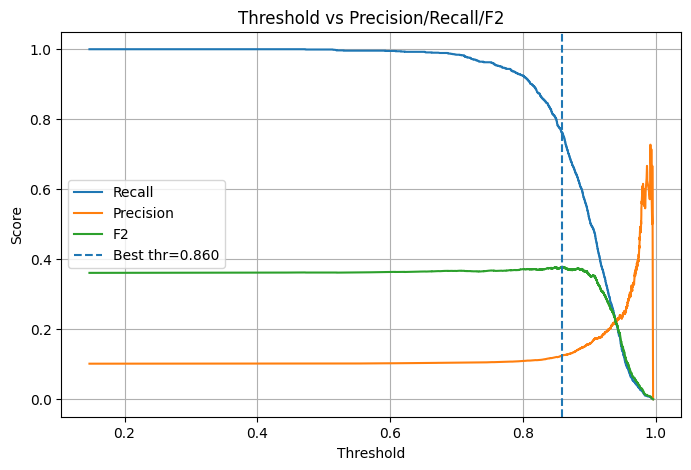

ROC_AUC:     0.6752819567207896
Accuracy:      0.44986907678013344
F1 score:      0.21990657563780094
Precision:     0.12753542650736316
Recall:        0.7975673327541268

Confusion matrix:

TN: 4408, FP: 6280, FN: 233, TP: 918

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.41      0.58     10688
           1       0.13      0.80      0.22      1151

    accuracy                           0.45     11839
   macro avg       0.54      0.60      0.40     11839
weighted avg       0.87      0.45      0.54     11839



In [38]:
xgb_pipe.test()

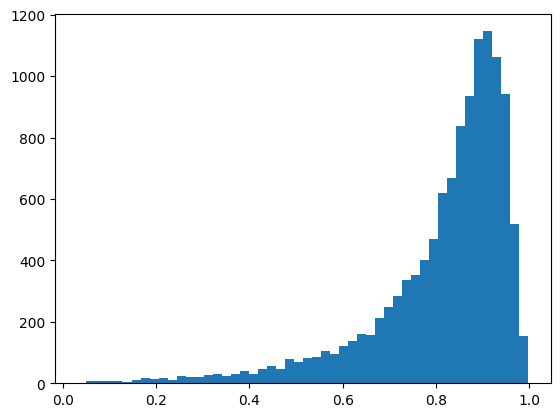

In [34]:
import matplotlib.pyplot as plt
from shared_util.dataio import load_csv



df = load_csv('cleaned')
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
plt.show()
